# Failure of National Electricity Transmission Network

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
import glob
import os

In [329]:
pd.set_option('display.max_rows', 500)

In [330]:
from vista_criticality_utils import *

In [416]:
# Reload modules
import importlib
import vista_criticality_utils
importlib.reload(vista_criticality_utils)
from vista_criticality_utils import *

# 1. Load assets to a new graph

In [332]:
asset_file = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/01-failure-of-national-electricity-transmission-network.csv'
dependency_file = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/01-dependency-mapping.csv'

In [333]:
incident_data = pd.read_csv(asset_file)
dependency_data = pd.read_csv(dependency_file)

In [335]:
incident_data.shape

(99, 7)

In [336]:
dependency_data.head(10)

,from_asset,to_asset,connection,dependency_score
0,PGS07,BSC04,PGS07-->BSC04,2
1,PGS07,TRR03,PGS07-->TRR03,2
2,PGS07,NH02,PGS07-->NH02,2
3,PGS07,TEL03,PGS07-->TEL03,2
4,PGS07,VH05,PGS07-->VH05,2
5,PGS07,NH04,PGS07-->NH04,2
6,PGS07,FS07,PGS07-->FS07,2
7,PGS04,FS03,PGS04-->FS03,2
8,PGS04,BSC02,PGS04-->BSC02,2
9,PGS04,SCH02,PGS04-->SCH02,2


In [337]:
dependency_data.shape

(78, 4)

Show Dependency Mapper Demo on Browser....

In [338]:
G = load_assets_to_graph(assets_filepath=asset_file)

Successfully loaded /home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/01-failure-of-national-electricity-transmission-network.csv
Added 99 nodes to the graph.


In [339]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working'}

# 2. Add Dependencies to Graph

In [340]:
G = add_dependencies_to_graph(graph=G, dependencies_filepath=dependency_file)


Successfully loaded /home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/01-dependency-mapping.csv
Added edges. The graph now has 78 edges.


In [341]:
## Add dependency score as node attributes
G = compute_dependency_score(G=G)

In [342]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working',
 'dependency_score': 2}

# 3. Exposure Score

In [345]:
flood_layers = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/New_exposure_score_data/flood_files'
heat_stress_layers = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/New_exposure_score_data/heat_stress_files'
landslide_layers = '/home/akutekwea/VISTA-Development/vista/data-science/criticality_demo/data/New_exposure_score_data/landslide_files'

In [346]:
# Construct the search pattern to find all .geojson files in the specified folder
flood_geojson_search_pattern = os.path.join(flood_layers, '*.geojson')
flood_geojson_file_paths = glob.glob(flood_geojson_search_pattern)

heat_geojson_search_pattern = os.path.join(heat_stress_layers, '*.geojson')
heat_geojson_file_paths = glob.glob(heat_geojson_search_pattern)

landslide_geojson_search_pattern = os.path.join(landslide_layers, '*.geojson')
landslide_geojson_file_paths = glob.glob(landslide_geojson_search_pattern)

In [347]:
incident_data = compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths)
incident_data.head(10)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,2
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,2,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,2,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,2,0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,2,2
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1


In [349]:
incident_data_with_heat_stress_layer = compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths, heat_files=heat_geojson_file_paths)

In [352]:
incident_data_with_heat_stress_landslide_layer= compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths, heat_files=heat_geojson_file_paths, landslide_files=landslide_geojson_file_paths)

In [353]:
incident_data_with_heat_stress_landslide_layer.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,3
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,2,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,2,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,2,0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,2,3
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1


In [355]:
incident_data = compute_exposure_score(assets_df=incident_data, flood_files=flood_geojson_file_paths)
incident_data.head(10)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,2
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,2,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,2,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,2,0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,2,2
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1


# 4. Redundancy Score

In [356]:
incident_data = compute_redundancy_score(df=incident_data)

### Add exposure and redundancy scores as graph node addtributes

In [358]:
G = add_attribute_from_df(G=G, df=incident_data, column_name='exposure_score')

Added exposure_score to the graph.


In [359]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working',
 'dependency_score': 2,
 'exposure_score': 1}

In [360]:
G = add_attribute_from_df(G=G, df=incident_data, column_name='redundancy_score')

Added redundancy_score to the graph.


In [361]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working',
 'dependency_score': 2,
 'exposure_score': 1,
 'redundancy_score': 1}

# 5. Compute Asset Score

In [362]:
G = compute_asset_score(G=G)

Added asset_score to assets.


In [363]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working',
 'dependency_score': 2,
 'exposure_score': 1,
 'redundancy_score': 1,
 'asset_score': 7}

# 6. Simulate failure

In [428]:
failed_nodes = simulate_failure(G=G, failed_node='PGS01', threshold=2)

Failing: PGS01
Propagated failure to: TRR04 (via dependency 2.0)
Propagated failure to: PH01 (via dependency 2.0)
Propagated failure to: TRR09 (via dependency 2.0)
Propagated failure to: BSC06 (via dependency 2.0)
Propagated failure to: TRF04 (via dependency 2.0)
Propagated failure to: VH01 (via dependency 2.0)
Propagated failure to: BSC10 (via dependency 2.0)
Propagated failure to: FS06 (via dependency 2.0)
Propagated failure to: TRF03 (via dependency 2.0)
Propagated failure to: FS05 (via dependency 2.0)
Propagated failure to: TRR10 (via dependency 2.0)
Propagated failure to: SCH04 (via dependency 2.0)
Propagated failure to: TRR08 (via dependency 2.0)
Propagated failure to: TEL07 (via dependency 2.0)
Propagated failure to: TRR05 (via dependency 2.0)


In [422]:
failed_nodes

['TRR04',
 'PH01',
 'TRR09',
 'BSC06',
 'TRF04',
 'VH01',
 'BSC10',
 'FS06',
 'TRF03',
 'FS05',
 'TRR10',
 'SCH04',
 'TRR08',
 'TEL07',
 'TRR05']

Initiating failure at node: PGS01
Propagated failure to: TRR04 (dependency: 2.00 >= 1)
Propagated failure to: PH01 (dependency: 2.00 >= 1)
Propagated failure to: TRR09 (dependency: 2.00 >= 1)
Propagated failure to: BSC06 (dependency: 2.00 >= 1)
Propagated failure to: TRF04 (dependency: 2.00 >= 1)
Propagated failure to: VH01 (dependency: 2.00 >= 1)
Propagated failure to: BSC10 (dependency: 2.00 >= 1)
Propagated failure to: FS06 (dependency: 2.00 >= 1)
Propagated failure to: TRF03 (dependency: 2.00 >= 1)
Propagated failure to: FS05 (dependency: 2.00 >= 1)
Propagated failure to: TRR10 (dependency: 2.00 >= 1)
Propagated failure to: SCH04 (dependency: 2.00 >= 1)
Propagated failure to: TRR08 (dependency: 2.00 >= 1)
Propagated failure to: TEL07 (dependency: 2.00 >= 1)
Propagated failure to: TRR05 (dependency: 2.00 >= 1)


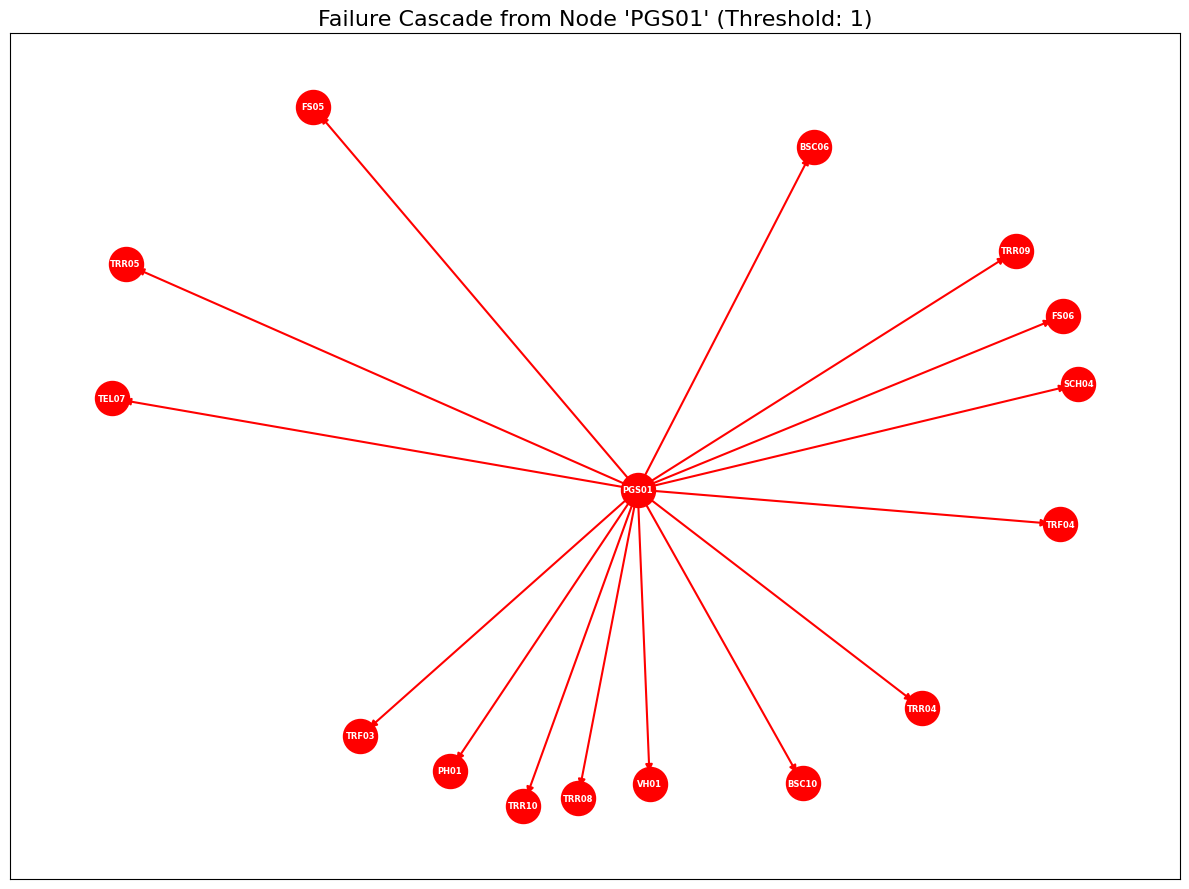

(['TRR04',
  'PH01',
  'TRR09',
  'BSC06',
  'TRF04',
  'VH01',
  'BSC10',
  'FS06',
  'TRF03',
  'FS05',
  'TRR10',
  'SCH04',
  'TRR08',
  'TEL07',
  'TRR05'],
 (<Figure size 1200x900 with 1 Axes>,
  <Axes: title={'center': "Failure Cascade from Node 'PGS01' (Threshold: 1)"}>))

In [429]:
simulate_failure_with_plot(G, failed_node='PGS01', threshold=1)

In [367]:
check_node_and_edges(G, 'PGS01')


--- Analysis for Node: PGS01 ---

[Asset Attributes]
  - Asset_ID: PGS01
  - Asset_Type: PowerGen/Substation
  - Asset_Name: LowVoltageElectricitySubstationComplex
  - lat: 50.719325
  - long: -1.2020439
  - criticality_score: 3
  - backup_asset_id: PGS02
  - status: failed
  - dependency_score: 2
  - exposure_score: 1
  - redundancy_score: 1
  - asset_score: 7

[Outgoing Dependencies (This asset depends on...)]
  -> PGS01 impacts VH01 with dependency_score (weight): 2.0
  -> PGS01 impacts SCH04 with dependency_score (weight): 2.0
  -> PGS01 impacts BSC06 with dependency_score (weight): 2.0
  -> PGS01 impacts TRR04 with dependency_score (weight): 2.0
  -> PGS01 impacts TEL07 with dependency_score (weight): 2.0
  -> PGS01 impacts TRR05 with dependency_score (weight): 2.0
  -> PGS01 impacts TRR10 with dependency_score (weight): 2.0
  -> PGS01 impacts TRR09 with dependency_score (weight): 2.0
  -> PGS01 impacts TRF03 with dependency_score (weight): 2.0
  -> PGS01 impacts PH01 with depend

# 7. Filter Graph by Criticality

In [368]:
G_criticality = filter_graph_by_criticality(G, threshold=3)


Filtered graph by criticality score >= 3.


In [369]:
G_criticality.number_of_nodes()

34

In [370]:
G_criticality.number_of_edges()

24

In [371]:
check_node_and_edges(G, 'PGS02')


--- Analysis for Node: PGS02 ---

[Asset Attributes]
  - Asset_ID: PGS02
  - Asset_Type: PowerGen/Substation
  - Asset_Name: HighVoltageElectricitySubstationComplex
  - lat: 50.710424
  - long: -1.2539468
  - criticality_score: 3
  - backup_asset_id: PGS03
  - status: working
  - dependency_score: 2
  - exposure_score: 0
  - redundancy_score: 1
  - asset_score: 6

[Outgoing Dependencies (This asset depends on...)]
  -> PGS02 impacts HS01 with dependency_score (weight): 2.0
  -> PGS02 impacts BSC01 with dependency_score (weight): 2.0
  -> PGS02 impacts TEL01 with dependency_score (weight): 2.0
  -> PGS02 impacts SCH01 with dependency_score (weight): 2.0
  -> PGS02 impacts FS02 with dependency_score (weight): 2.0
  -> PGS02 impacts SCH05 with dependency_score (weight): 2.0
  -> PGS02 impacts VH02 with dependency_score (weight): 2.0
  -> PGS02 impacts NH03 with dependency_score (weight): 2.0

[Incoming Dependencies (...depend on this asset)]
  - None
------------------------------


In [372]:
G_criticality.nodes()

NodeView(('PGS02', 'WS02', 'TEL10', 'SW02', 'TEL04', 'TEL09', 'PGS01', 'SW01', 'PGS04', 'TEL03', 'GS01', 'TRF02', 'TRF03', 'WS03', 'SW04', 'PGS03', 'TRF04', 'WS01', 'TEL02', 'WS05', 'PGS07', 'TEL08', 'PGS08', 'PGS06', 'SW03', 'TEL06', 'TRF01', 'TEL01', 'HS01', 'WS04', 'TEL11', 'TEL05', 'PGS05', 'TEL07'))

Initiating failure at node: PGS02
Propagated failure to: HS01 (dependency: 2.00 >= 1.0)
Propagated failure to: TEL01 (dependency: 2.00 >= 1.0)


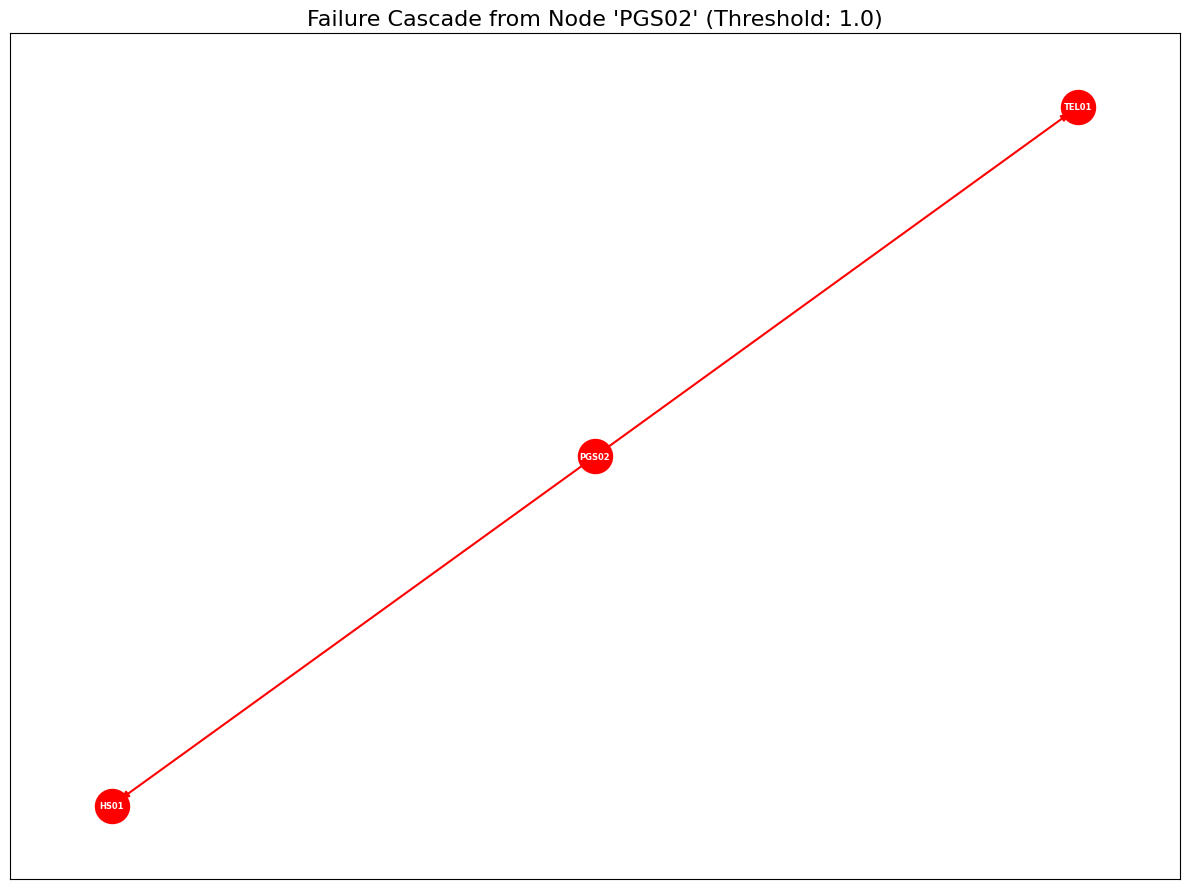

(['HS01', 'TEL01'],
 (<Figure size 1200x900 with 1 Axes>,
  <Axes: title={'center': "Failure Cascade from Node 'PGS02' (Threshold: 1.0)"}>))

In [373]:
simulate_failure_with_plot(G_criticality, 'PGS02') #Only Criticality 3 assets shown